# Analyse exploratoire des données — Dataset Adult (Census Income)

> **Objectif :** Explorer le dataset `adult.data` afin d'identifier les facteurs liés au revenu
> (`>50K` vs `<=50K`), en vue de construire un modèle de classification performant.
>
> **Source :** [UCI Machine Learning Repository - Adult Data Set](https://archive.ics.uci.edu/dataset/2/adult)
>
> **Auteurs :** Nickels Ethan

---

## Table des matières
**Analyse classique**
1. [Importation des librairies](#section-1)
2. [Chargement et aperçu des données](#section-2)
3. [Description des variables](#section-3)
4. [Statistiques descriptives](#section-4)
5. [Identification des types de variables](#section-5)
6. [Valeurs manquantes](#section-6)
7. [Distribution de la variable cible](#section-7)
8. [Analyse univariée - variables numériques](#section-8)
9. [Analyse univariée - variables catégorielles](#section-9)
10. [Analyse bivariée - impact sur le revenu](#section-10)
11. [Corrélations](#section-11)

**Analyse originale**
12. [Questionnements pertinents](#section-12)
13. [Réflexion originale : biais et variables cachées](#section-13)
14. [Conclusion](#section-14)

---
## 1. Importation des librairies <a id='section-1'></a>
On importe les librairies nécessaires à l'analyse :
- **pandas** et **numpy** : manipulation et traitement des données tabulaires.
- **matplotlib** et **seaborn** : création de graphiques.
- **scipy.stats** : tests statistiques et distributions.

In [17]:
import pandas as pd
import numpy as np

# Esthétique et visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Outils statistiques
import scipy.stats as stats

sns.set_style("whitegrid")
pd.pandas.set_option('display.max_columns', None)

---
## 2. Chargement et aperçu des données <a id='section-2'></a>
Le fichier `adult.data` est un fichier texte séparé par des virgules, sans en-tête.
On lui attribue donc explicitement les noms de colonnes décrits dans `adult.names`.
Le fichier est chargé depuis le répertoire courant (chemin relatif), tel qu'exigé par les consignes.

In [18]:
column_names = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

def load_adult_data(path):
    """Charge le fichier adult.data et nettoie les espaces superflus."""
    df = pd.read_csv(path, header=None, names=column_names,
                      sep=',', skipinitialspace=True, na_values='?')
    return df

df_data = load_adult_data('adult.data')
df_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Le dataset contient **32561 individus** (lignes) et **15 variables** (colonnes), dont la variable
cible `income`. On y trouve des informations démographiques (âge, sexe, origine), socio-économiques
(niveau d'éducation, profession, statut marital) et financières (gains/pertes en capital, heures
travaillées).

---
## 3. Description des variables <a id='section-3'></a>
Avant toute analyse statistique, on décrit la signification de chacune des 15 variables du dataset
(issue de la documentation `adult.names`), afin de pouvoir interpréter correctement les résultats
qui suivent.

In [19]:
variable_descriptions = pd.DataFrame([
    ("age", "numérique", "Âge de l'individu, en années."),
    ("workclass", "catégorielle", "Type d'employeur (privé, public, indépendant, sans emploi...)."),
    ("fnlwgt", "numérique", "Poids d'échantillonnage du recensement (nombre de personnes que "
                             "l'individu est censé représenter dans la population) - pas une "
                             "caractéristique de l'individu lui-même."),
    ("education", "catégorielle", "Niveau d'éducation atteint (ex. HS-grad, Bachelors, Doctorate)."),
    ("education_num", "numérique", "Version numérique ordonnée du niveau d'éducation."),
    ("marital_status", "catégorielle", "Statut marital (marié, célibataire, divorcé, veuf...)."),
    ("occupation", "catégorielle", "Type de profession exercée."),
    ("relationship", "catégorielle", "Rôle familial de l'individu (époux, enfant, non apparenté...)."),
    ("race", "catégorielle", "Origine ethnique déclarée."),
    ("sex", "catégorielle", "Sexe déclaré de l'individu."),
    ("capital_gain", "numérique", "Gains en capital déclarés (investissements) sur l'année."),
    ("capital_loss", "numérique", "Pertes en capital déclarées sur l'année."),
    ("hours_per_week", "numérique", "Nombre d'heures travaillées par semaine."),
    ("native_country", "catégorielle", "Pays de naissance de l'individu."),
    ("income", "catégorielle (cible)", "Revenu annuel : `<=50K` ou `>50K` — variable à prédire."),
], columns=["Variable", "Type", "Description"])

variable_descriptions

,Variable,Type,Description
0,age,numérique,"Âge de l'individu, en années."
1,workclass,catégorielle,"Type d'employeur (privé, public, indépendant, ..."
2,fnlwgt,numérique,Poids d'échantillonnage du recensement (nombre...
3,education,catégorielle,"Niveau d'éducation atteint (ex. HS-grad, Bache..."
4,education_num,numérique,Version numérique ordonnée du niveau d'éducation.
5,marital_status,catégorielle,"Statut marital (marié, célibataire, divorcé, v..."
6,occupation,catégorielle,Type de profession exercée.
7,relationship,catégorielle,"Rôle familial de l'individu (époux, enfant, no..."
8,race,catégorielle,Origine ethnique déclarée.
9,sex,catégorielle,Sexe déclaré de l'individu.


Cette description confirme deux points utiles pour la suite : `education_num` est l'équivalent
numérique ordonné d'`education` (les deux portent la même information, ce qui sera à prendre en
compte pour éviter une redondance lors de la sélection de variables en Phase 3), et `fnlwgt` est un
artefact méthodologique du recensement plutôt qu'une caractéristique individuelle, ce qui confirme
sa mise à l'écart envisagée plus loin dans l'analyse.

---
## 4. Statistiques descriptives <a id='section-4'></a>
`info()` donne un aperçu des types de données et du nombre de valeurs non-nulles par colonne.
`describe()` fournit les statistiques de base (moyenne, écart-type, quartiles) pour les variables
numériques. Ces deux fonctions permettent d'identifier rapidement des anomalies.

In [20]:
df_data.info()
print("-" * 60)
df_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
------------------------------------------------------------


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


On observe que le dataset ne contient, en apparence, aucune valeur nulle (`non-null` partout) : les
valeurs manquantes du dataset original sont en réalité codées par le caractère `?`, que nous avons
converti en `NaN` au chargement (voir section suivante).
La variable `capital_gain` présente un maximum (99999) très largement supérieur à sa moyenne et sa
médiane, ce qui suggère la présence d'une valeur plafond (cap) artificielle plutôt que de vrais
outliers statistiques.

---
## 5. Identification des types de variables <a id='section-5'></a>
On distingue les variables numériques continues des variables catégorielles, afin d'adapter le
prétraitement ultérieur (encodage, normalisation, etc.).

In [21]:
def identify_variable_types(df, discrete_threshold=20):
    """Classe les colonnes d'un dataframe en numériques continues, numériques discrètes
    et catégorielles, selon leur dtype et leur nombre de valeurs uniques."""
    numeric_cols, categorical_cols = [], []
    for col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_cols.append(col)
        else:
            categorical_cols.append(col)
    print(f"Variables numériques ({len(numeric_cols)}) : {numeric_cols}")
    print(f"Variables catégorielles ({len(categorical_cols)}) : {categorical_cols}")
    return numeric_cols, categorical_cols

numeric_cols, categorical_cols = identify_variable_types(df_data)

Variables numériques (6) : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
Variables catégorielles (9) : ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


Le dataset comporte **6 variables numériques** continues (`age`, `fnlwgt`, `education_num`,
`capital_gain`, `capital_loss`, `hours_per_week`) et **9 variables catégorielles**, dont la cible
`income`. Cette répartition guidera le choix des techniques de prétraitement (encodage pour le
catégoriel, mise à l'échelle pour le numérique).

---
## 6. Valeurs manquantes <a id='section-6'></a>
On quantifie les valeurs manquantes (`?` converties en `NaN`) par colonne.

In [22]:
def missing_values(df):
    """Retourne un résumé du nombre et du pourcentage de valeurs manquantes par colonne."""
    n_missing = df.isnull().sum()
    pct_missing = (n_missing / len(df) * 100).round(2)
    summary = pd.DataFrame({'n_missing': n_missing, 'pct_missing': pct_missing})
    return summary[summary['n_missing'] > 0].sort_values('n_missing', ascending=False)

missing_values(df_data)

,n_missing,pct_missing
occupation,1843,5.66
workclass,1836,5.64
native_country,583,1.79


Trois variables présentent des valeurs manquantes : `workclass` (~5.6%), `occupation` (~5.7%) et
`native_country` (~1.8%). Ces proportions restent faibles (moins de 6% par variable) : une
imputation (mode) ou une suppression ciblée sera envisageable en Phase 2 sans perte d'information
majeure.

---
## 7. Distribution de la variable cible <a id='section-7'></a>
On visualise la répartition de la variable cible `income`, qui conditionne le choix des métriques
d'évaluation du futur modèle (accuracy seule insuffisante si déséquilibre marqué).

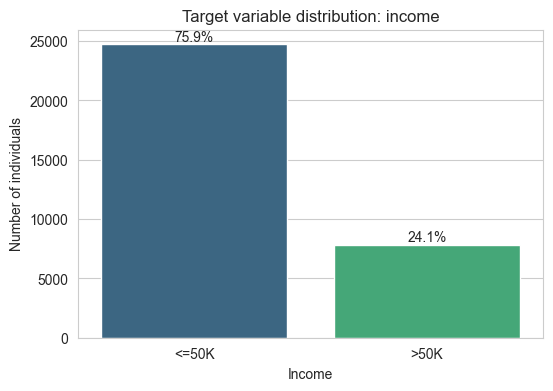

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64

In [23]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='income', data=df_data, hue='income', palette='viridis', legend=False)
plt.title("Target variable distribution: income")
plt.xlabel("Income")
plt.ylabel("Number of individuals")
for p in ax.patches:
    pct = 100 * p.get_height() / len(df_data)
    ax.annotate(f'{pct:.1f}%', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()

df_data['income'].value_counts(normalize=True) * 100

Le dataset est **fortement déséquilibré** : environ 76% des individus gagnent `<=50K` contre 24%
`>50K`. Ce déséquilibre a deux conséquences importantes : (1) l'accuracy seule sera un indicateur
trompeur pour évaluer les futurs modèles (un modèle qui prédit toujours `<=50K` obtiendrait ~76%
d'accuracy sans être utile), il faudra privilégier des métriques comme le F1-score ou l'AUC-ROC ;
(2) un rééquilibrage (class_weight, sous/sur-échantillonnage) pourra être envisagé en modélisation.

---
## 8. Analyse univariée — variables numériques <a id='section-8'></a>
On visualise la distribution des principales variables numériques à l'aide d'histogrammes et de
boxplots, afin de repérer forme de distribution et valeurs extrêmes.

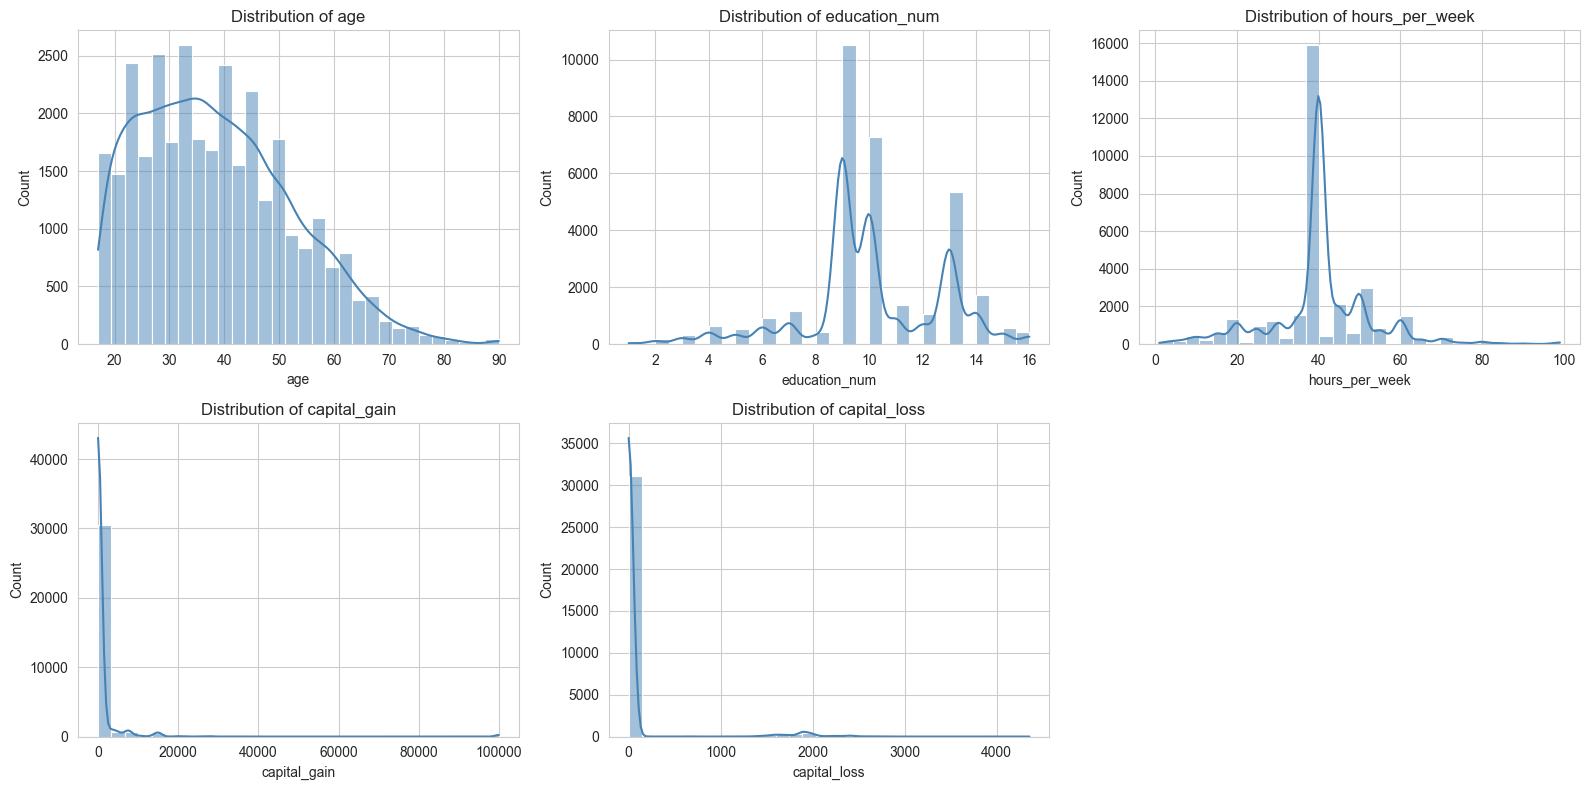

In [24]:
num_features = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(num_features):
    sns.histplot(df_data[col], bins=30, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis('off')
plt.tight_layout()
plt.show()

- **age** : distribution asymétrique à droite, la majorité des individus a entre 25 et 45 ans.
- **education_num** : plusieurs pics correspondant aux niveaux d'éducation typiques (9 = HS-grad,
  13 = Bachelors...), cohérent avec son caractère ordinal encodé.
- **hours_per_week** : très concentrée autour de 40h (semaine de travail standard), avec des queues
  vers le temps partiel et le sur-temps.
- **capital_gain** et **capital_loss** : très majoritairement nulles, avec une minorité d'individus
  présentant des valeurs élevées (voire plafonnées à 99999 pour `capital_gain`) — ces variables sont
  fortement asymétriques et devront être traitées spécifiquement (ex. transformation log, ou
  variable binaire "a du capital-gain").

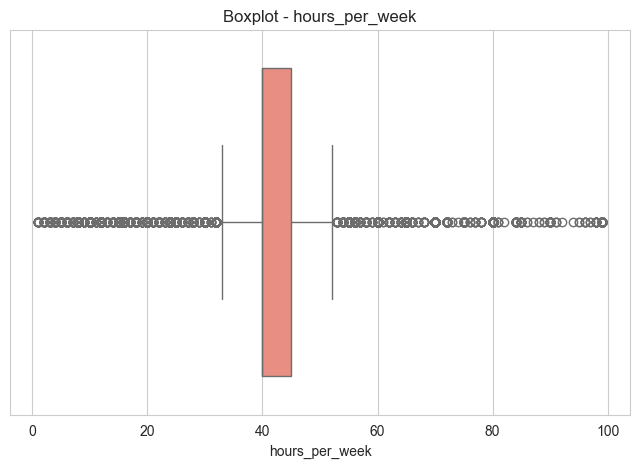

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_data['hours_per_week'], color='salmon')
plt.title("Boxplot - hours_per_week")
plt.show()

Le boxplot confirme la présence de valeurs extrêmes pour `hours_per_week` (individus travaillant
très peu ou au contraire plus de 80h/semaine). Ces valeurs restent plausibles dans un contexte de
recensement (temps partiel, cumul d'emplois) et ne semblent pas être des erreurs de saisie ; elles
seront conservées mais pourront être surveillées lors de la modélisation.

---
## 9. Analyse univariée — variables catégorielles <a id='section-9'></a>
On visualise la fréquence des modalités des principales variables catégorielles.

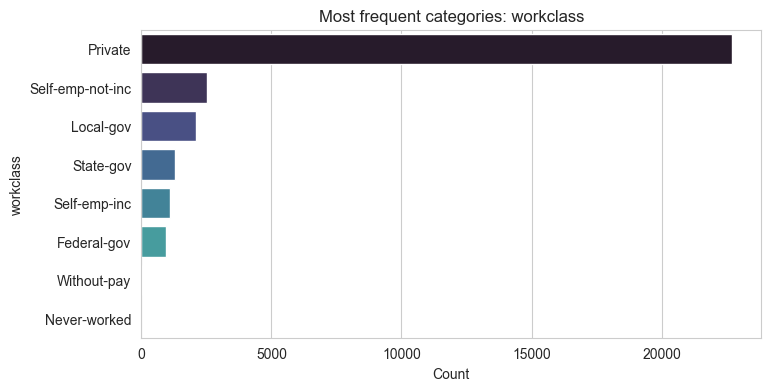

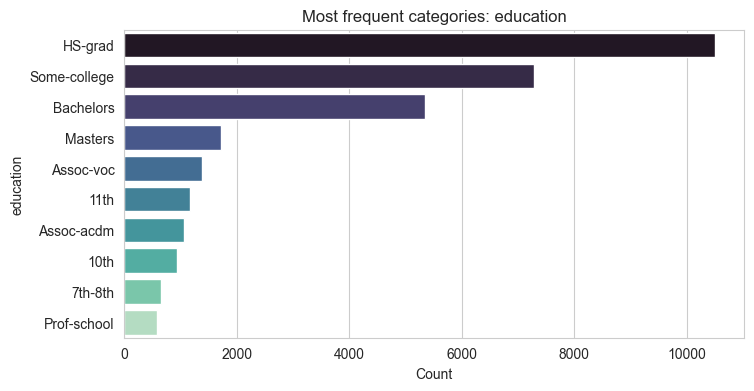

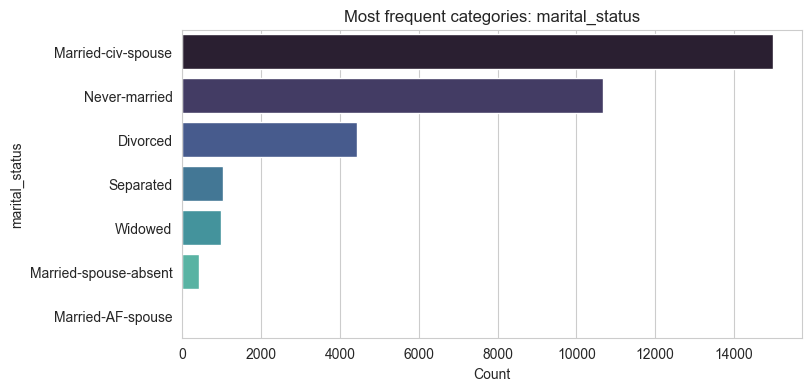

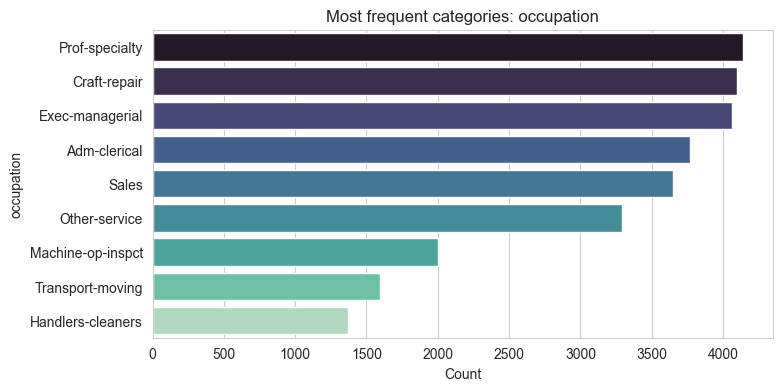

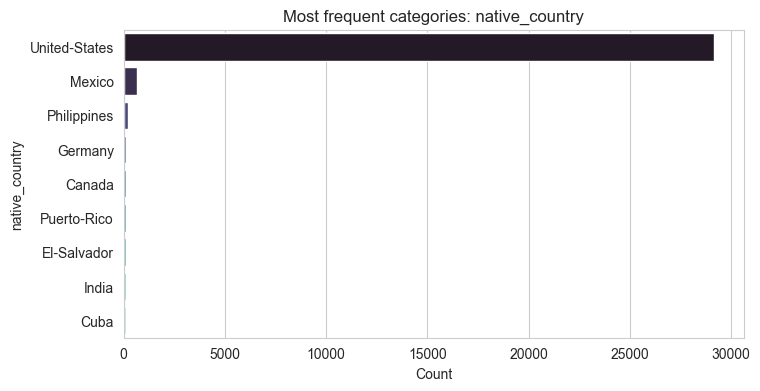

In [26]:
def plot_categorical_distribution(df, col, top_n=10):
    """Affiche un barplot des modalités les plus fréquentes d'une variable catégorielle."""
    counts = df[col].value_counts(dropna=False).head(top_n)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index, hue=counts.index, palette='mako', legend=False)
    plt.title(f"Most frequent categories: {col}")
    plt.xlabel("Count")
    plt.show()

for col in ['workclass', 'education', 'marital_status', 'occupation', 'native_country']:
    plot_categorical_distribution(df_data, col)

- **workclass** : très largement dominé par `Private` (secteur privé), ce qui limitera son pouvoir
  discriminant sauf pour les modalités rares (ex. `Without-pay`).
- **education** : `HS-grad`, `Some-college` et `Bachelors` regroupent la majorité des individus.
- **marital_status** : `Married-civ-spouse` et `Never-married` dominent.
- **occupation** : distribution assez équilibrée entre une dizaine de catégories professionnelles.
- **native_country** : très fortement dominé par `United-States` (>90%), les autres pays sont
  minoritaires — cette variable sera probablement peu informative une fois regroupée.

---
## 10. Analyse bivariée — impact sur le revenu <a id='section-10'></a>
On formule ici des **questionnements pertinents** (impact de l'éducation, du genre, de l'âge sur le
revenu) et on y répond par la visualisation croisée avec la variable cible `income`.

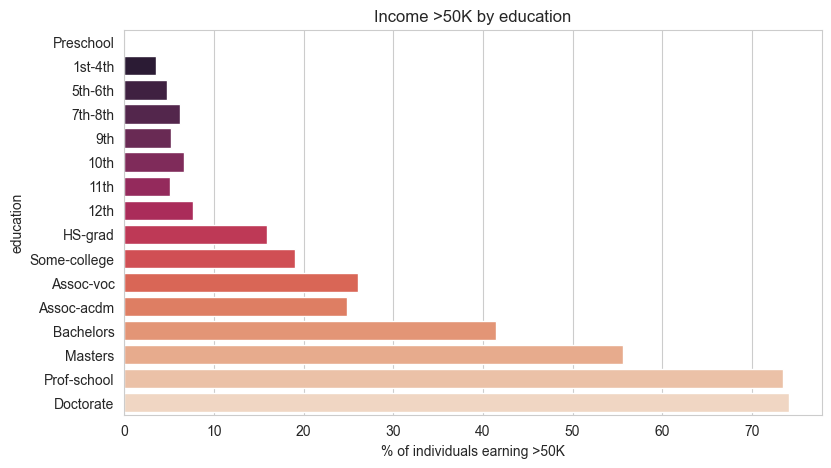

education
Preschool        0.000000
1st-4th          3.571429
5th-6th          4.804805
7th-8th          6.191950
9th              5.252918
10th             6.645230
11th             5.106383
12th             7.621247
HS-grad         15.950862
Some-college    19.023454
Assoc-voc       26.121563
Assoc-acdm      24.835989
Bachelors       41.475257
Masters         55.658735
Prof-school     73.437500
Doctorate       74.092010
Name: income, dtype: float64

In [27]:
def plot_income_by_feature(df, feature, order=None, figsize=(9, 5)):
    """Affiche la proportion de revenu >50K pour chaque modalité d'une variable catégorielle."""
    prop = (df.groupby(feature)['income']
              .apply(lambda s: (s == '>50K').mean() * 100)
              .sort_values(ascending=False))
    if order is not None:
        prop = prop.reindex(order)
    plt.figure(figsize=figsize)
    sns.barplot(x=prop.values, y=prop.index, hue=prop.index, palette='rocket', legend=False)
    plt.xlabel("% of individuals earning >50K")
    plt.title(f"Income >50K by {feature}")
    plt.show()
    return prop

# Question 1 : l'éducation influence-t-elle le revenu ?
edu_order = df_data.groupby('education')['education_num'].mean().sort_values().index
plot_income_by_feature(df_data, 'education', order=edu_order)

**Réponse à la question 1 :** oui, la relation est nette et monotone : la proportion d'individus
gagnant `>50K` augmente quasi continûment avec le niveau d'éducation, passant de quasiment 0% pour
`Preschool` à plus de 70% pour `Doctorate`/`Prof-school`. `education_num` (sa version numérique déjà
présente dans le dataset) sera donc une variable très prédictive.

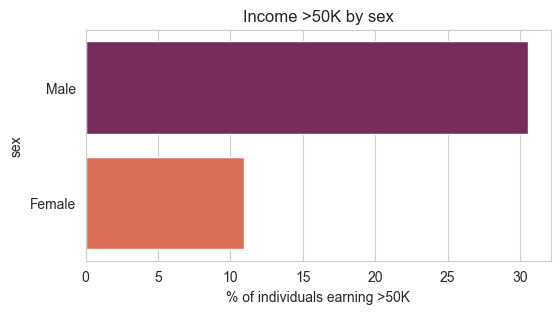

sex
Male      30.573658
Female    10.946059
Name: income, dtype: float64

In [28]:
# Question 2 : le genre influence-t-il le revenu ?
plot_income_by_feature(df_data, 'sex', figsize=(6, 3))

**Réponse à la question 2 :** un écart important apparaît entre les sexes : environ 30% des hommes
gagnent `>50K` contre environ 11% des femmes. Cet écart peut refléter un véritable écart salarial
mais aussi des effets de composition (temps partiel plus fréquent chez les femmes, secteurs
d'activité différents) — ce point est repris dans la réflexion sur les biais (section 12).

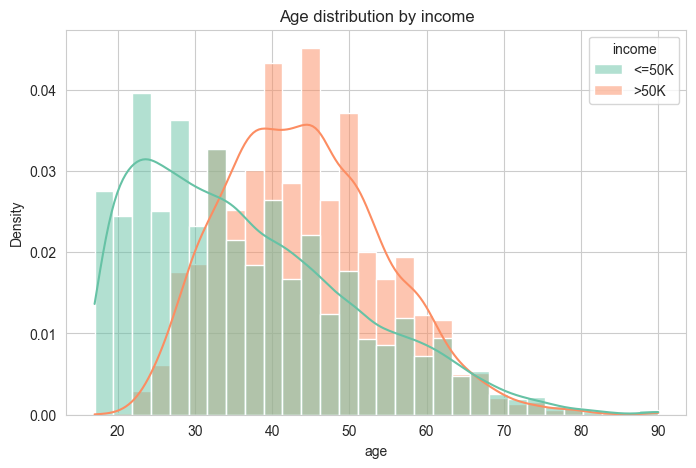

In [29]:
# Question 3 : l'âge influence-t-il le revenu ?
plt.figure(figsize=(8, 5))
sns.histplot(data=df_data, x='age', hue='income', kde=True, bins=30, palette='Set2',
             stat='density', common_norm=False)
plt.title("Age distribution by income")
plt.show()

**Réponse à la question 3 :** la relation n'est pas linéaire. Les hauts revenus (`>50K`) sont rares
avant 30 ans (début de carrière) et se concentrent surtout entre 35 et 55 ans, avant de redécliner
après 60 ans (retraite progressive). L'âge seul est donc moins discriminant qu'une combinaison
âge × expérience/éducation.

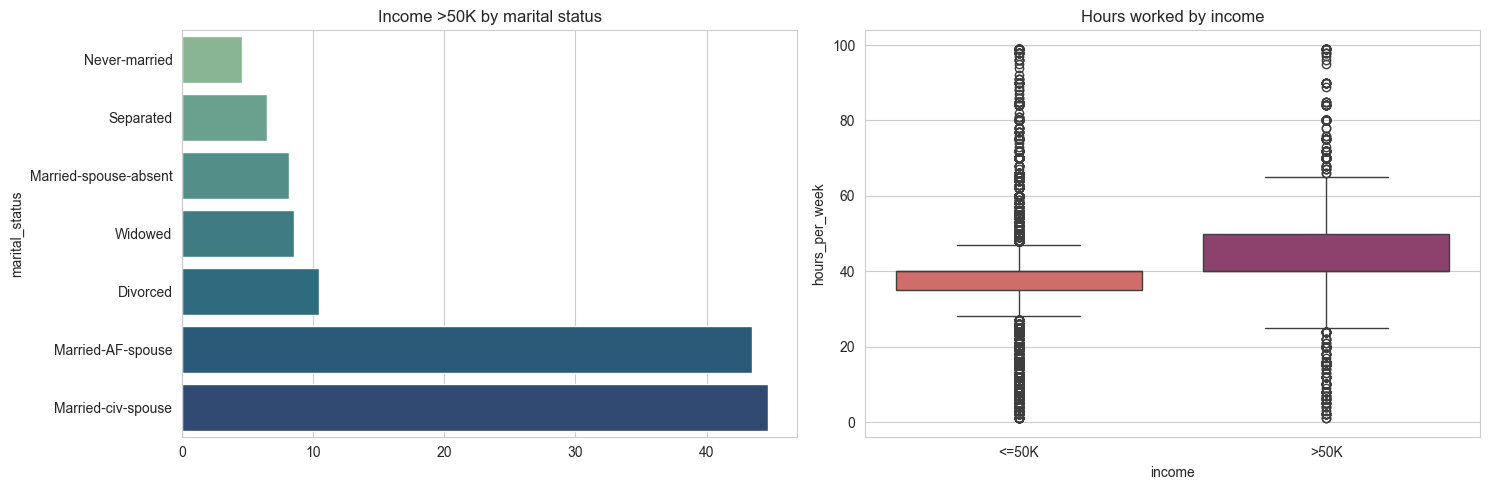

In [30]:
# Question 4 : le statut marital et le nombre d'heures travaillées influencent-ils le revenu ?
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
prop_marital = (df_data.groupby('marital_status')['income']
                 .apply(lambda s: (s == '>50K').mean() * 100).sort_values())
sns.barplot(x=prop_marital.values, y=prop_marital.index, ax=axes[0],
            hue=prop_marital.index, palette='crest', legend=False)
axes[0].set_title("Income >50K by marital status")

sns.boxplot(data=df_data, x='income', y='hours_per_week', ax=axes[1], hue='income',
            palette='flare', legend=False)
axes[1].set_title("Hours worked by income")
plt.tight_layout()
plt.show()

**Réponse à la question 4 :** les personnes mariées (`Married-civ-spouse`) affichent la plus forte
proportion de hauts revenus, très au-dessus des célibataires ou divorcés — ce résultat est à
nuancer : le statut marital est probablement corrélé à l'âge (donc à l'expérience professionnelle)
plutôt que causal en soi. Le nombre d'heures travaillées est également clairement plus élevé chez
les `>50K`, ce qui est cohérent (temps plein, postes à responsabilité).

---
## 11. Corrélations <a id='section-11'></a>
On calcule la matrice de corrélation entre les variables numériques (Pearson), ainsi que leur
corrélation avec une version binarisée de la cible.

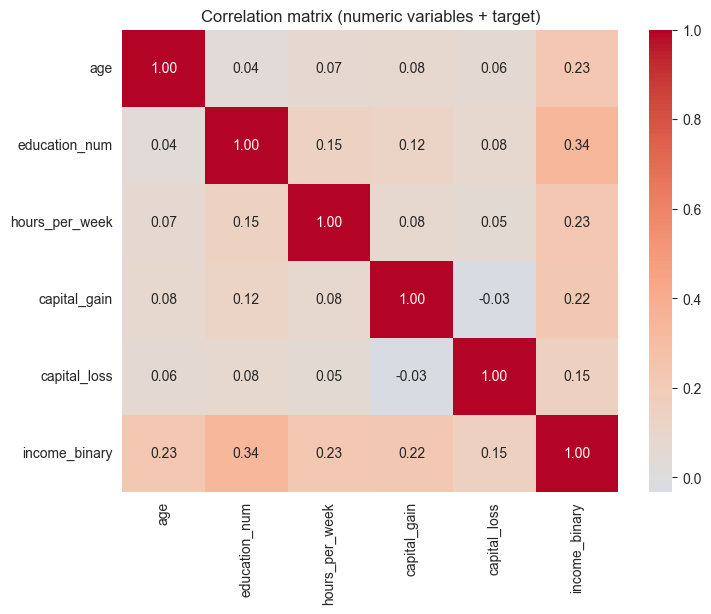

In [31]:
df_corr = df_data.copy()
df_corr['income_binary'] = (df_corr['income'] == '>50K').astype(int)
corr_cols = num_features + ['income_binary']

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[corr_cols].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Correlation matrix (numeric variables + target)")
plt.show()

`education_num` est la variable numérique la plus corrélée (positivement) avec le revenu, suivie de
`age` et `hours_per_week`. `capital_gain` a une corrélation linéaire faible malgré son fort pouvoir
discriminant observé plus haut — la relation entre `capital_gain` et le revenu n'est pas linéaire
(effet de seuil : la simple présence d'un gain en capital, même faible, est plus informative que sa
valeur exacte), Pearson sous-estime donc son importance réelle.

---
## 12. Questionnements pertinents <a id='section-12'></a>
Au-delà des questions déjà explorées (éducation, genre, âge, statut marital, heures travaillées),
d'autres questionnements mériteraient une analyse approfondie en Phase 2/3/4 :
- La combinaison `education_num` × `hours_per_week` permet-elle de mieux séparer les classes qu'une
  variable seule (interaction) ?
- La variable `native_country`, très déséquilibrée, apporte-t-elle un gain réel une fois regroupée
  en grandes zones géographiques, ou est-elle surtout du bruit ?
- Le déséquilibre homme/femme dans le revenu persiste-t-il à profession et heures travaillées
  identiques (toutes choses égales par ailleurs), ou s'explique-t-il en grande partie par la
  composition des professions occupées ?
- `fnlwgt` (poids statistique du recensement) a-t-il un quelconque pouvoir prédictif, ou doit-il
  être exclu du modèle car il ne décrit pas l'individu mais la méthodologie d'échantillonnage ?

---
## 13. Réflexion originale : biais et variables cachées <a id='section-13'></a>
Quelques pistes de réflexion critique sur le dataset :

- **Biais de genre / temporel** : les données datent du recensement américain de 1994. Les écarts de
  revenu observés entre hommes et femmes reflètent la société de l'époque et ne doivent pas être
  interprétés comme une vérité intemporelle ; un modèle entraîné sur ces données risque de
  reproduire (voire d'amplifier) ce biais historique s'il est utilisé sans précaution.
- **`fnlwgt` (final weight)** : cette variable ne décrit pas l'individu mais représente un poids
  d'échantillonnage du recensement (nombre de personnes que cet individu est censé représenter dans
  la population). L'inclure tel quel dans un modèle prédictif n'a pas de sens métier ; elle sera
  candidate à l'exclusion en Phase 2.
- **Variable cachée "expérience professionnelle"** : le dataset ne contient pas directement le
  nombre d'années d'expérience ; `age` et `education_num` en sont des proxys imparfaits, ce qui peut
  limiter la performance des modèles pour des profils atypiques (reconversion tardive, etc.).
- **Corrélation ≠ causalité pour `marital_status`** : comme noté en section 9, le lien entre statut
  marital et revenu est probablement en grande partie porté par l'âge et non par le mariage en soi.
- **Plafonnement de `capital_gain`** : la valeur maximale de 99999 suggère un plafonnement
  volontaire des données lors de leur anonymisation, ce qui écrase artificiellement les très hauts
  revenus en capital et peut biaiser tout modèle utilisant cette variable telle quelle.

---
## 14. Conclusion <a id='section-14'></a>
Cette analyse exploratoire met en évidence un dataset globalement propre (peu de valeurs
manquantes), mais **déséquilibré** sur la cible et porteur de **biais socio-historiques** à garder
en tête. `education_num`, `age`, `hours_per_week`, `capital_gain`/`capital_loss` et `sex` se
dégagent comme les variables les plus prometteuses pour la modélisation, tandis que `fnlwgt` et,
dans une moindre mesure, `native_country` semblent peu informatives. Ces constats orienteront
directement les choix de prétraitement (Phase 2) et de sélection de variables (Phase 3).